In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [ ]:
df = pd.read_csv("modified_data.csv")

In [ ]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,233.58
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,653.15
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,177.20
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,210.00
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,283.51


In [ ]:
df = df.drop(columns=['date','statezip','street'])

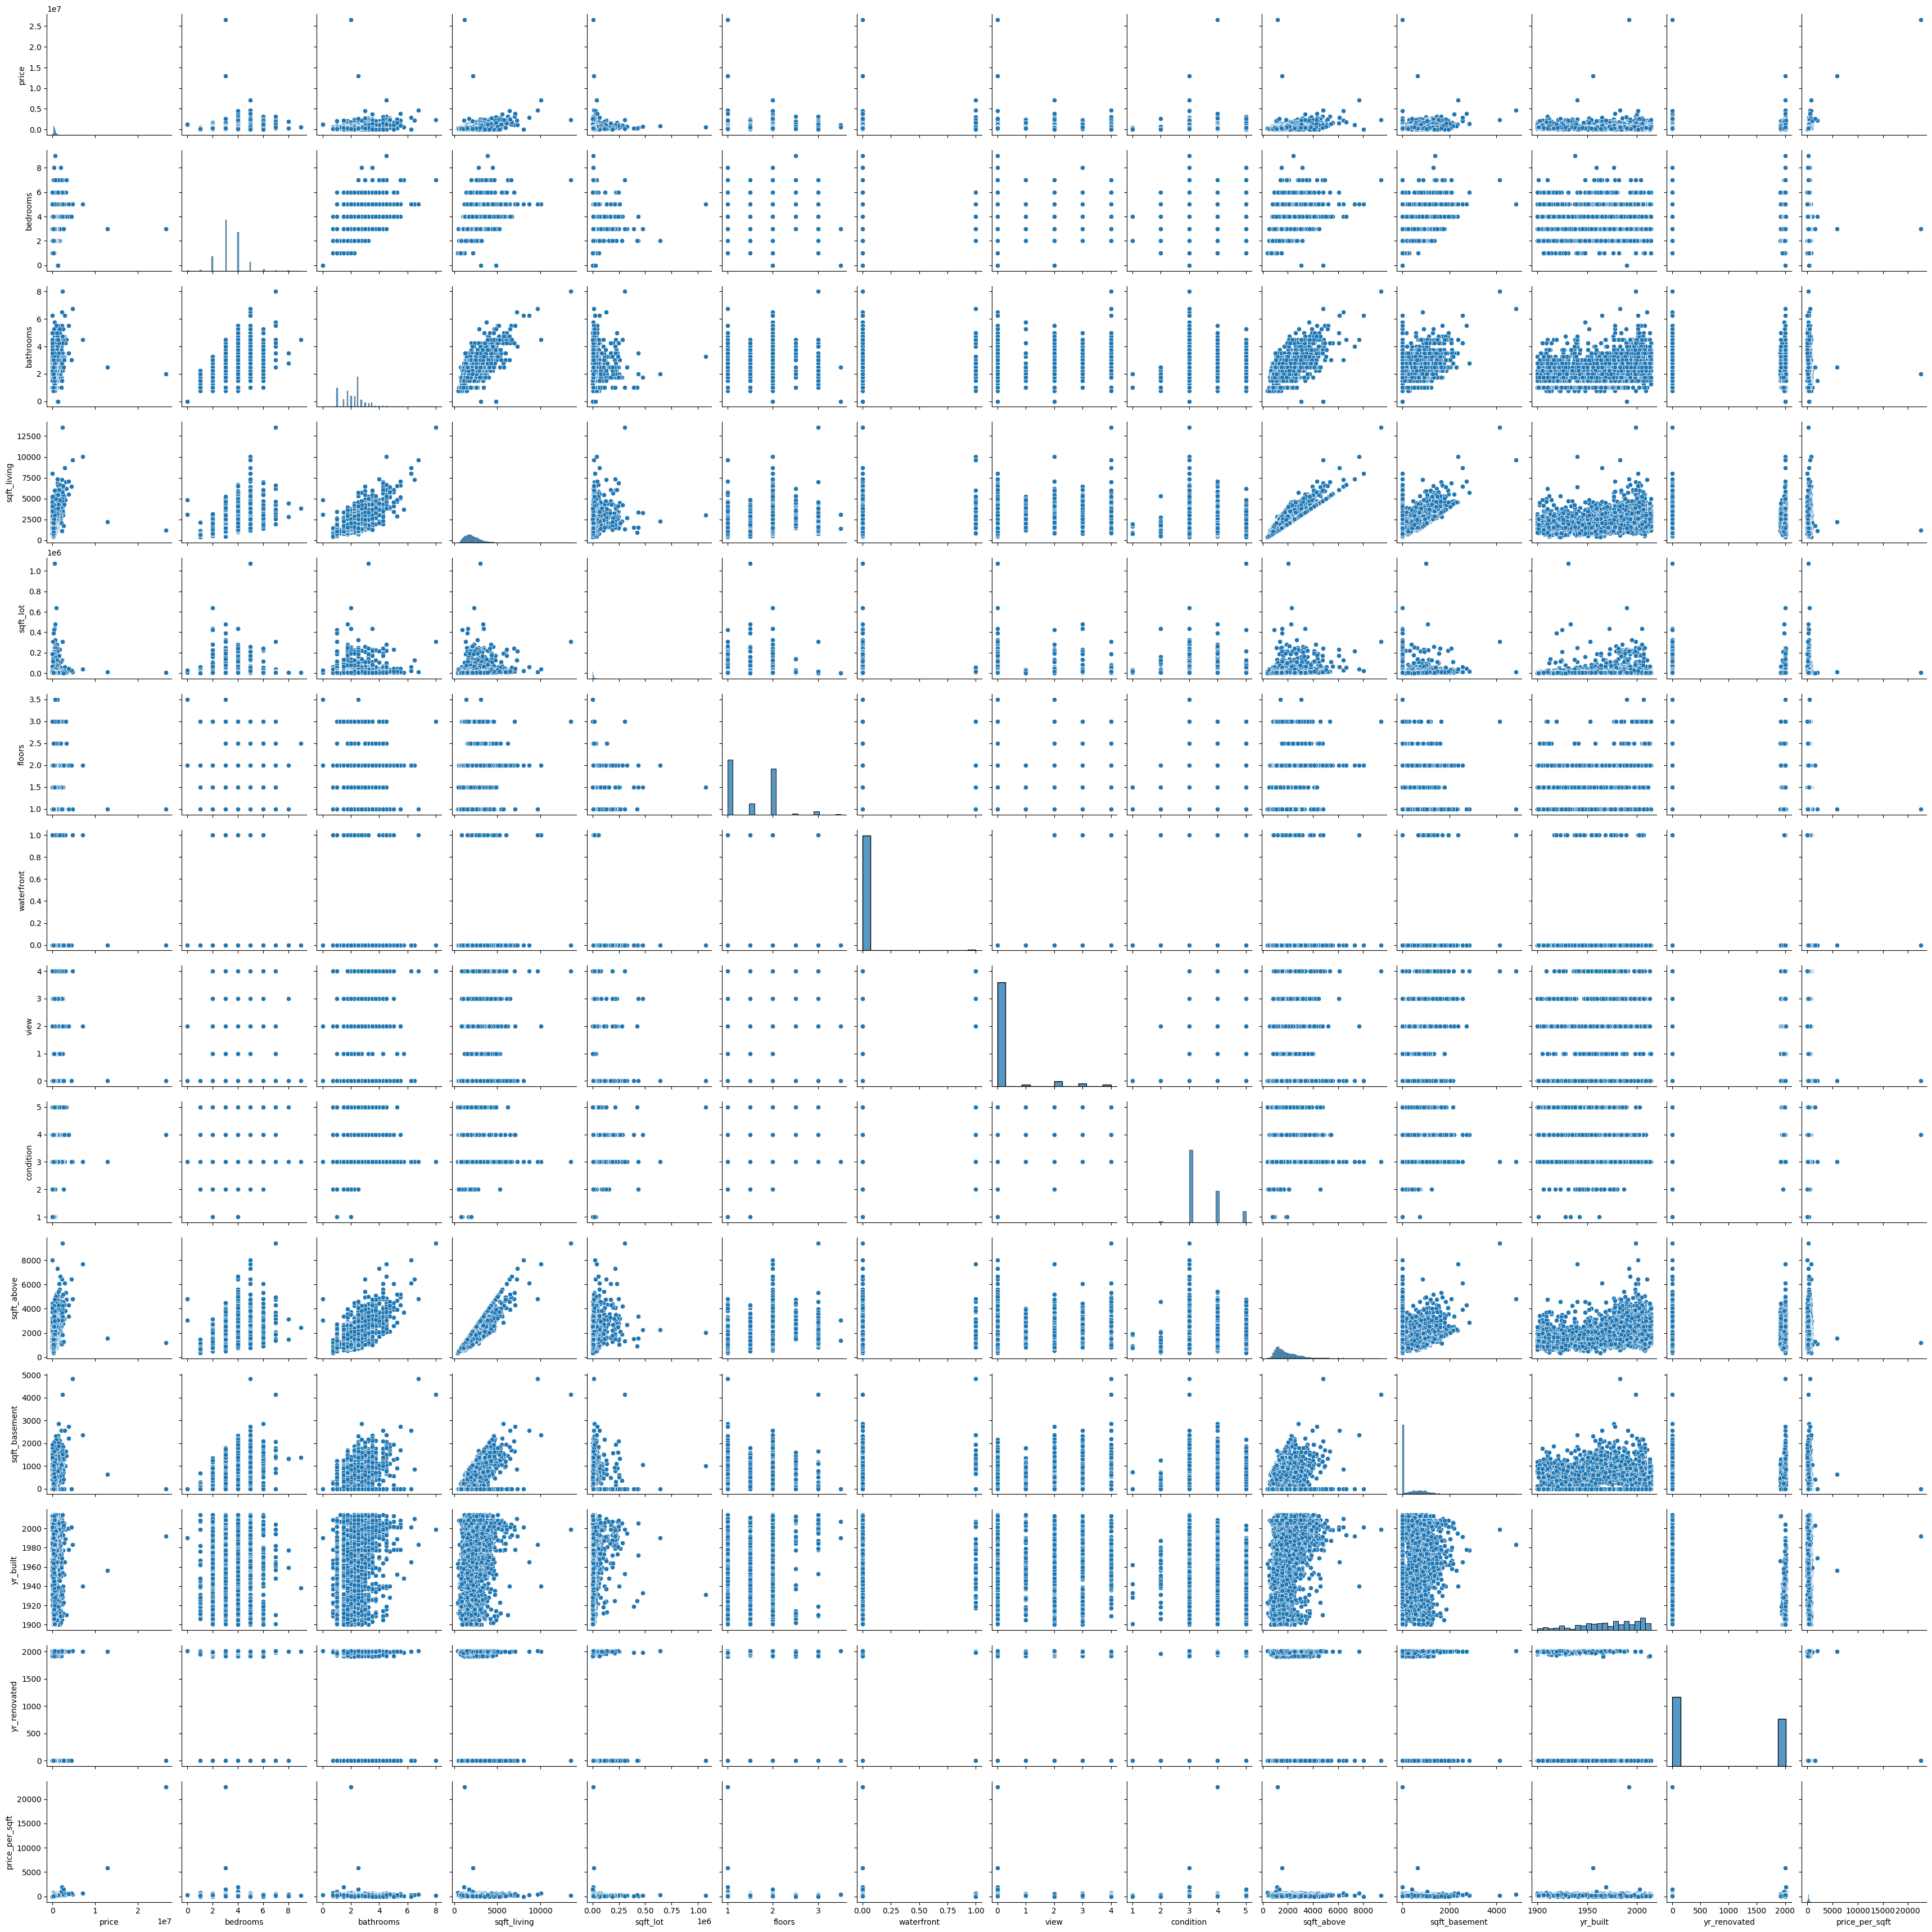

In [ ]:
sns.pairplot(df)

<Axes: >

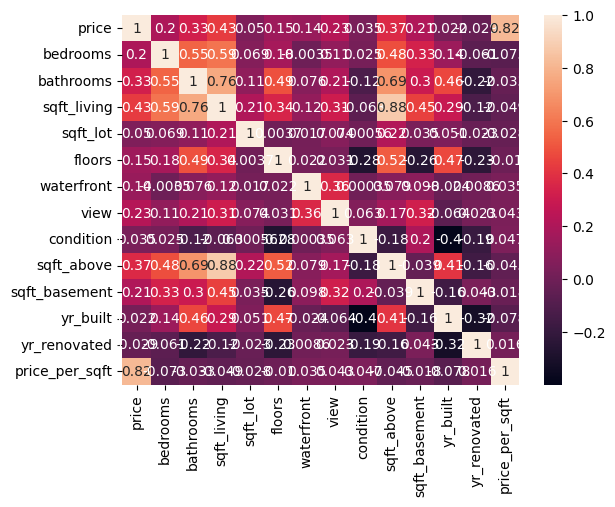

In [ ]:
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True)

In [ ]:
df['yr_renovated'].value_counts()

,count
yr_renovated,
0,2735
2000,170
2003,151
2009,109
2001,109
2005,95
2004,77
2014,72
2006,68


In [ ]:
X = df.drop('price',axis=1)
y = df['price']

In [ ]:
num = X.select_dtypes(include=np.number).columns
cat = X.select_dtypes(exclude=np.number).columns

In [ ]:
num_x = Pipeline(steps=[
    ('impute',SimpleImputer(strategy='median')),
    ('scale',StandardScaler())
])
cat_x = Pipeline(steps=[
    ('impute',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown='ignore'))
])


In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('num',num_x,num),
    ('cat',cat_x,cat)
])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
lr = LinearRegression()

In [ ]:
model = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',lr)
])

In [ ]:
model.fit(X_train,y_train)
y_pred = model.predict(X_test)


In [ ]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R2 Score: {r2}")

Mean Squared Error: 526921246726.2391
Mean Absolute Error: 96868.95474068543
R2 Score: 0.48333270805924333


In [ ]:
y_pred2 = model.predict(X_train)
mse2 = mean_squared_error(y_train,y_pred2)
mae2 = mean_absolute_error(y_train,y_pred2)
r22 = r2_score(y_train,y_pred2)

In [ ]:
print(f"Mean Squared Error: {mse2}")
print(f"Mean Absolute Error: {mae2}")
print(f"R2 Score: {r22}")


Mean Squared Error: 17034968566.20975
Mean Absolute Error: 69914.11808433653
R2 Score: 0.8801079547167632
